# Notebook 1 - Exploratory Data Analysis and Preprocessing

Afonso Fernandes 20241710

Lourenço Lima 20241711

Lucas Casimiro 20241796

## Imports

In [2]:
import os
import sys
import warnings
from pathlib import Path

def _find_project_root(start, marker="requirements.txt"):
    path = Path(start).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / marker).exists():
            return str(candidate)
    raise RuntimeError(f"Could not find project root (marker={marker!r}, searched from {start})")

PROJECT_ROOT = _find_project_root(os.path.abspath("."))
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import math
from sklearn.preprocessing import RobustScaler
import pickle

from functions.eda import *
from functions.preprocessing import *
from functions.utils import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Preliminary Data Analysis

### 1.1 Data Loading

In [ ]:
customer_info = pd.read_csv('data/customer_info.csv')
customer_basket = pd.read_csv('data/customer_basket.csv')
display(customer_info)

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,...,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,...,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,...,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235


,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807
...,...,...,...
99995,7685930,"['yams', 'airpods', 'shrimp']",21357
99996,2998960,"['cake', 'chocolate bread', 'cologne', 'beer',...",7817
99997,4409376,"['chicken', 'frozen smoothie', 'milk', 'body s...",35497
99998,3650163,"['metroid fusion', 'cat food', 'melons', 'ring...",13412


### 1.2 Data Types

In [5]:
display(f'Datatypes:\n {customer_info.info()}')

<class 'pandas.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  str    
 2   customer_gender                          33038 non-null  str    
 3   customer_birthdate                       32873 non-null  str    
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377 non-null  

'Datatypes:\n None'

### 1.3 Missing Values

In [9]:
display("Number of missing values per column:")
customer_info.isnull().sum()

'Number of missing values per column:'

customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

For a better understanding, we plotted the percentages of missing values for the non-filled columns.

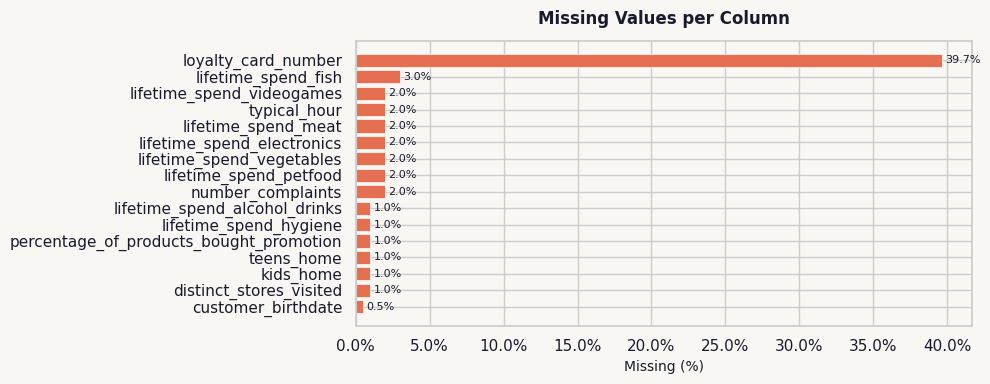

In [10]:
plot_missing_values(customer_info)

We can see that there's only 1 column with a high missing value percentage: `loyalty_card_number`. From observing the dataset, we know that it only has 1 value, which is 1. We will fill the missing values with 0 in the appropriate section, and consider the variable to be a boolean, where `1 = has card` and `0 = doesn't have card`.

### 1.4 Statistical Info

In [11]:
customer_info.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,33038.0,19974.265785,11538.538632,3.000000,9985.250000,19951.500000,29964.750000,40000.000000
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000


In most lifetime_ columns, the mean is higher than the median and the maximum is a lot higher than the 75th percentile, indicating right-skewness, and meaning there's probably some customers with a much higher spending overall than most.

Also, there is a negative minimum in the column `percentage_of_products_bought_promotion`, which is impossible, as a percentage is meant to be between 0% and 100% or 0 and 1 (which is the case here, as the maximum is 1.0). To fix this, we clipped the bounds in between 0 and 1 (as there's no steps until preprocessing which would need these incorrect values). 

In [ ]:
customer_info['percentage_of_products_bought_promotion'] = customer_info['percentage_of_products_bought_promotion'].clip(lower=0.0, upper=1.0)

There's also transactions in the future in the column `year_first_transaction`, which will be dealt with in the feature engineering section.

## 2. Preprocessing and Feature Engineering